# Voyage Analytics — Feature Engineering

**Notebook:** `04_Feature_Engineering` · **Phase:** Feature store / modelling prep
**Module:** `src/features/features.py` · **Produces:** `data/processed/gender_features.csv`,
`user_hotel_interactions.csv`, `hotel_catalog.csv`

---

### Where this sits
`src.data_ingestion` produced the **entity tables** — cleaned sources plus `trips` and
`users_features`. This layer builds the **model-ready feature sets** on top of them, one per
remaining model:

```
trips.csv · users_features.csv · hotels_clean.csv
     │
     ├─ build_gender_features()     ─▶ gender_features.csv          (objective #8)
     ├─ build_user_hotel_matrix()   ─▶ user_hotel_interactions.csv  (objective #9)
     └─ build_hotel_catalog()       ─▶ hotel_catalog.csv            (objective #9)
```

It also centralises two things every model needs:

| Piece | Why it exists |
|---|---|
| **`FEATURE_REGISTRY`** | A declarative catalogue of every engineered feature — the lightweight stand-in for the PRD's *feature store*. One documented definition, so training and serving cannot silently disagree. |
| **`make_preprocessor()`** | One shared encoder factory (one-hot + impute + scale) instead of a copy per model. |

> **Performance note.** Same convention as the earlier notebooks: heavy work runs once via
> `python -m src.features`; this notebook drives and inspects, so it stays light on memory.


## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#08A045", "#6BBF59", "#F2C14E", "#F78154", "#B4436C", "#4C6EF5"]

from src.utils import PATHS
print("processed dir:", PATHS.processed)

processed dir: F:\Final Project Labmentix\voyage-analytics\data\processed


## 1. The feature registry

Every engineered feature is declared once, with its source and meaning. This is what a
production feature store formalises; keeping it in code costs nothing and prevents the classic
train/serve skew where a feature is computed one way in the notebook and another way in the API.

In [2]:
from src.features import registry_frame, FEATURE_REGISTRY

print(f"{len(FEATURE_REGISTRY)} features registered")
display(registry_frame())

18 features registered


,name,dtype,source,description
0,age,int,users,Traveller age in years (21-65)
1,company,category,users,Employer; deterministically encodes home city
2,home_city,category,trips,Most frequent outbound origin
3,n_trips,int,trips,Frequency: completed round trips
4,recency_days,int,trips,Days since last departure (snapshot = max date)
5,total_spend,float,trips,Monetary: flight + hotel spend
6,flight_spend,float,trips,Lifetime spend on flights
7,hotel_spend,float,hotels,Lifetime spend on hotels
8,avg_trip_spend,float,trips,Mean spend per trip
9,avg_trip_nights,float,trips,Mean trip length in nights (1-4)


## 2. Behaviour aggregation — the new signal

EDA's blunt finding was that **demographics do not predict customer value** (age/company/gender
all showed ~zero correlation with spend). So the useful signal has to be *behavioural*.

`build_user_behaviour()` derives that from the trip table: not just how much someone travels, but
**how** — their mix of flight classes and agencies, typical trip length, distance and destination
variety.

In [3]:
from src.data_ingestion import load_processed, load_interim
from src.features import build_user_behaviour

trips = load_processed("trips")
behaviour = build_user_behaviour(trips)
print("behaviour features:", behaviour.shape)
display(behaviour.head())

17:01:55 | INFO    | ingest | loaded trips                (135944, 15) from trips.csv


17:01:55 | INFO    | features | user behaviour features: (1335, 11)


behaviour features: (1335, 11)


,avg_trip_nights,avg_distance,avg_flight_cost,avg_trip_spend,n_destinations,share_class_economic,share_class_firstClass,share_class_premium,share_agency_CloudFy,share_agency_FlyingDrops,share_agency_Rainbow
user,,,,,,,,,,,
0,2.5618,527.2336,1978.1322,2158.0752,9,0.2472,0.4944,0.2584,0.4382,0.1798,0.3820
1,1.1667,508.6483,1637.7967,1702.2500,5,0.3333,0.1667,0.5000,0.6667,0.1667,0.1667
2,2.6641,513.6714,1813.8437,1967.1881,9,0.3359,0.3740,0.2901,0.4275,0.0916,0.4809
3,2.3417,506.0744,1873.8278,2024.4515,9,0.2864,0.4322,0.2814,0.4322,0.1407,0.4271
4,2.5578,517.9555,1914.7868,2073.8708,9,0.2412,0.4523,0.3065,0.4121,0.1508,0.4372


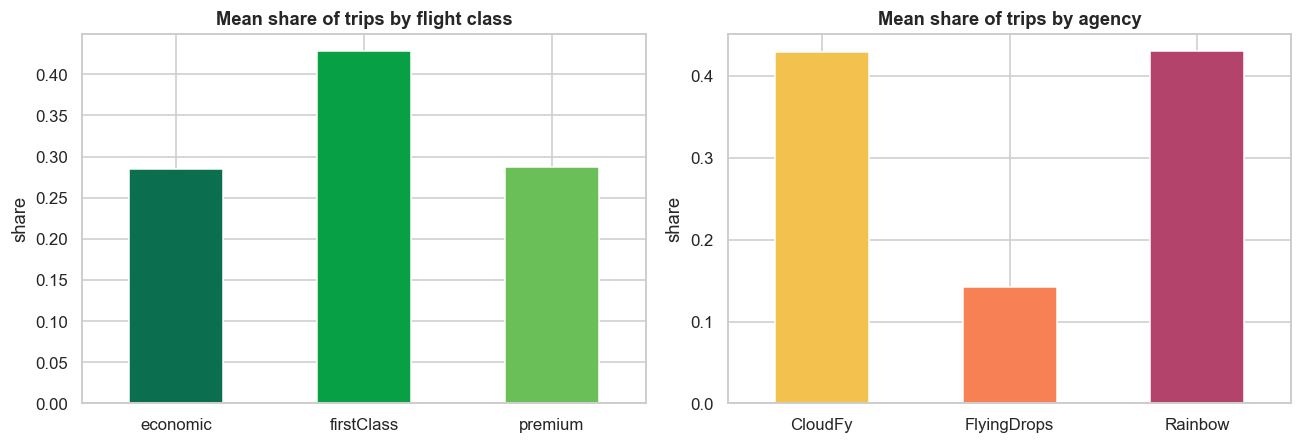

In [4]:
share_cols = [c for c in behaviour.columns if c.startswith("share_")]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

cls = [c for c in share_cols if "class" in c]
behaviour[cls].mean().plot(kind="bar", ax=ax[0], color=PAL[:3])
ax[0].set_title("Mean share of trips by flight class"); ax[0].set_ylabel("share")
ax[0].set_xticklabels([c.replace("share_class_", "") for c in cls], rotation=0)

agy = [c for c in share_cols if "agency" in c]
behaviour[agy].mean().plot(kind="bar", ax=ax[1], color=PAL[3:6])
ax[1].set_title("Mean share of trips by agency"); ax[1].set_ylabel("share")
ax[1].set_xticklabels([c.replace("share_agency_", "") for c in agy], rotation=0)

plt.tight_layout()
PATHS.figures.mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "19_behaviour_shares.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** The average traveller splits roughly 43% first class / 29% premium / 29% economic,
and books Rainbow and CloudFy about equally with a smaller FlyingDrops share — consistent with
FlyingDrops being first-class-only. These *mix* features vary far more between individuals than any
demographic does, which is precisely why they are the ones worth feeding the models.

## 3. Gender-classification feature set (objective #8)

Keeps every user, with `gender_known` separating the two populations:
**train** on the labelled male/female rows, then **impute** the ~33% labelled `none`.

One deliberate exclusion: **`name` is dropped**. Predicting gender from a first name would leak the
answer through a lookup rather than learn anything from travel behaviour — and it would fail on
exactly the ambiguous names where a prediction is actually wanted.

In [5]:
from src.features import (build_gender_features, GENDER_CAT_FEATURES,
                          GENDER_NUM_FEATURES, GENDER_TARGET)

gender = build_gender_features()
print("categorical:", GENDER_CAT_FEATURES)
print("numeric    :", GENDER_NUM_FEATURES)
print("target     :", GENDER_TARGET)
print("\nshape:", gender.shape)
display(gender.head())

17:01:56 | INFO    | ingest | loaded users_features       (1340, 19) from users_features.csv


17:01:57 | INFO    | ingest | loaded trips                (135944, 15) from trips.csv


17:01:57 | INFO    | features | user behaviour features: (1335, 11)


17:01:57 | INFO    | features | gender features: (1340, 23) | labelled (male/female): 900 | to impute (none): 440


categorical: ['company', 'home_city']
numeric    : ['age', 'n_trips', 'recency_days', 'total_spend', 'flight_spend', 'hotel_spend', 'avg_trip_spend', 'avg_trip_nights', 'avg_distance', 'n_destinations', 'hotel_attach_rate']
target     : gender

shape: (1340, 23)


,code,gender,gender_known,is_active,company,home_city,age,n_trips,recency_days,total_spend,...,avg_trip_nights,avg_distance,n_destinations,hotel_attach_rate,share_class_economic,share_class_firstClass,share_class_premium,share_agency_CloudFy,share_agency_FlyingDrops,share_agency_Rainbow
0,0,male,True,True,4You,Brasilia (DF),21,89.0,781.0,192068.69,...,2.5618,527.2336,9.0,0.3034,0.2472,0.4944,0.2584,0.4382,0.1798,0.3820
1,1,male,True,True,4You,Aracaju (SE),37,6.0,1362.0,10213.50,...,1.1667,508.6483,5.0,0.3333,0.3333,0.1667,0.5000,0.6667,0.1667,0.1667
2,2,female,True,True,4You,Aracaju (SE),48,131.0,487.0,257701.64,...,2.6641,513.6714,9.0,0.2748,0.3359,0.3740,0.2901,0.4275,0.0916,0.4809
3,3,female,True,True,4You,Brasilia (DF),23,199.0,11.0,402865.84,...,2.3417,506.0744,9.0,0.3015,0.2864,0.4322,0.2814,0.4322,0.1407,0.4271
4,4,female,True,True,4You,Recife (PE),44,199.0,11.0,412700.28,...,2.5578,517.9555,9.0,0.2814,0.2412,0.4523,0.3065,0.4121,0.1508,0.4372


In [6]:
labelled = gender[gender["gender_known"]]
print("labelled (train pool):", len(labelled), "| to impute (gender='none'):", int((~gender['gender_known']).sum()))
print("\nclass balance in the labelled pool:")
print(labelled[GENDER_TARGET].value_counts().to_string())

labelled (train pool): 900 | to impute (gender='none'): 440

class balance in the labelled pool:
gender
male      452
female    448
none        0


### 3.1 Do the features actually separate the classes?

Worth checking **before** training, not after. If the engineered features carry no signal about
gender, the honest conclusion is that the model will sit near chance — better to know now than to
present an inflated accuracy later.

In [7]:
num = [c for c in GENDER_NUM_FEATURES if c in labelled.columns]
comp = labelled.groupby(GENDER_TARGET, observed=True)[num].mean().T
comp["abs_diff_%"] = ((comp["male"] - comp["female"]).abs() / comp.mean(axis=1) * 100).round(2)
display(comp.round(2).sort_values("abs_diff_%", ascending=False))

gender,female,male,abs_diff_%
avg_distance,545.02,551.75,1.23
avg_trip_spend,2063.10,2086.97,1.15
age,43.18,42.70,1.11
hotel_spend,16365.98,16221.73,0.89
recency_days,688.53,694.29,0.83
n_trips,102.21,101.39,0.81
total_spend,211910.64,211079.75,0.39
hotel_attach_rate,0.30,0.30,0.36
flight_spend,195544.66,194858.02,0.35
avg_trip_nights,2.51,2.50,0.27


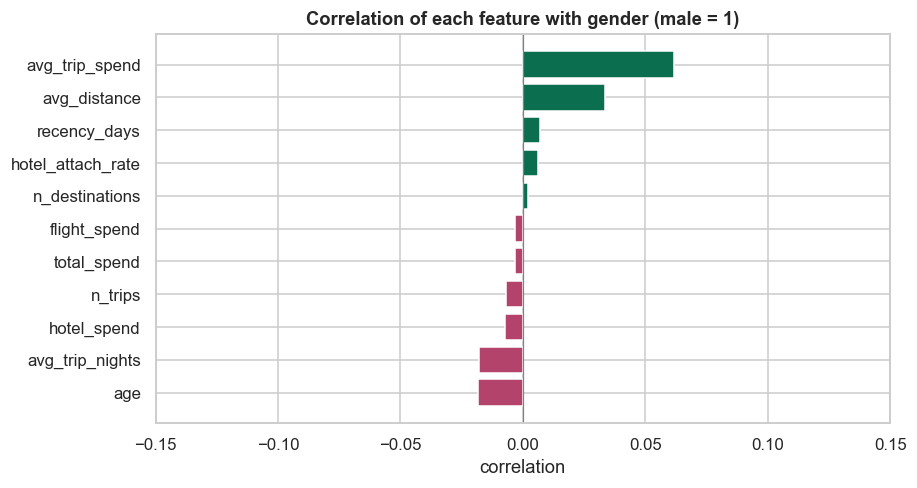

strongest |correlation|: 0.0617


In [8]:
# Point-biserial style check: correlation of each numeric feature with the binary target
y = (labelled[GENDER_TARGET] == "male").astype(int)
corrs = labelled[num].apply(lambda s: s.corr(y)).sort_values()

plt.figure(figsize=(8.5, 4.6))
colors = [PAL[5] if v < 0 else PAL[0] for v in corrs.values]
plt.barh(range(len(corrs)), corrs.values, color=colors)
plt.yticks(range(len(corrs)), corrs.index)
plt.axvline(0, color="grey", lw=0.8)
plt.xlim(-0.15, 0.15)
plt.title("Correlation of each feature with gender (male = 1)")
plt.xlabel("correlation")
plt.tight_layout()
plt.savefig(PATHS.figures / "20_gender_signal.png", dpi=130, bbox_inches="tight")
plt.show()
print("strongest |correlation|:", corrs.abs().max().round(4))

**Insight — and an honest expectation.** Every feature correlates with gender at essentially
zero, and the male/female group means differ by only a few percent. The classes are well balanced
(~50/50), so there is no imbalance problem — there is simply **very little signal**.

**What this means:** the gender classifier should be expected to land near **~50% accuracy**, not
the >75% quoted as the project's generic success bar. That is a property of the dataset (gender was
generated independently of behaviour), not a modelling failure. The right move is to report it
plainly with a proper baseline comparison rather than tune until a number looks respectable — and to
treat the `none` values as *undisclosed* rather than confidently imputing them.

## 4. Recommender feature sets (objective #9)

Two halves of a hybrid recommender:
- **`user_hotel_interactions`** — long-format user × hotel implicit feedback (bookings, nights, spend).
- **`hotel_catalog`** — per-hotel content features (city, nightly rate, popularity, revenue).

In [9]:
from src.features import build_user_hotel_matrix, build_hotel_catalog

interactions = build_user_hotel_matrix()
catalog = build_hotel_catalog()
print("interactions:", interactions.shape); display(interactions.head())
print("catalog:", catalog.shape); display(catalog)

17:01:57 | INFO    | ingest | loaded hotels_clean         (40552, 10) from hotels_clean.csv


17:01:57 | INFO    | features | user-hotel interactions: (9724, 6) | users=1310 hotels=9


17:01:58 | INFO    | ingest | loaded hotels_clean         (40552, 10) from hotels_clean.csv


17:01:58 | INFO    | features | hotel catalog: (9, 7)


interactions: (9724, 6)


,user,hotel,bookings,nights,spend,last_stay
0,0,Hotel A,3,7,2191.14,2020-10-15
1,0,Hotel AF,4,11,1530.10,2021-05-20
2,0,Hotel AU,2,5,1564.15,2021-05-27
3,0,Hotel BD,4,9,2185.92,2021-04-15
4,0,Hotel BP,1,4,990.48,2021-02-18


catalog: (9, 7)


,hotel,place,nightly_rate,bookings,unique_guests,avg_nights,revenue
0,Hotel AU,Recife (PE),312.83,4467,1130,2.521,3522778.63
1,Hotel K,Salvador (BH),263.41,5094,1158,2.516,3376652.79
2,Hotel BD,Natal (RN),242.88,4829,1152,2.499,2931075.84
3,Hotel BP,Brasilia (DF),247.62,4437,1120,2.486,2731743.84
4,Hotel A,Florianopolis (SC),313.02,3330,749,2.483,2588362.38
5,Hotel Z,Aracaju (SE),208.04,4205,1106,2.492,2179635.08
6,Hotel CB,Rio de Janeiro (RJ),165.99,5029,1166,2.486,2075206.98
7,Hotel AF,Sao Paulo (SP),139.10,4828,1151,2.512,1686726.60
8,Hotel BW,Campo Grande (MS),60.39,4333,992,2.495,652997.07


users=1310  hotels=9  observed pairs=9,724
matrix density = 82.5%


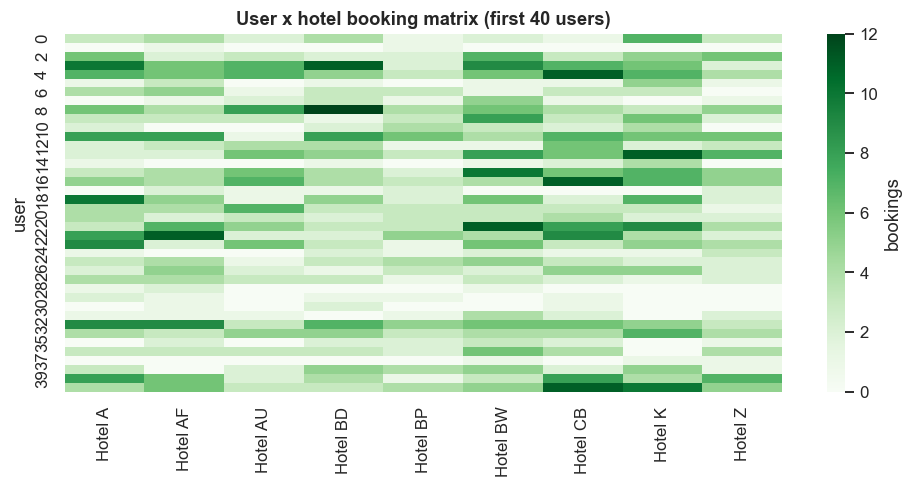

In [10]:
n_users, n_hotels = interactions["user"].nunique(), interactions["hotel"].nunique()
density = len(interactions) / (n_users * n_hotels)
print(f"users={n_users}  hotels={n_hotels}  observed pairs={len(interactions):,}")
print(f"matrix density = {density:.1%}")

pivot = interactions.pivot_table(index="user", columns="hotel", values="bookings", fill_value=0)
plt.figure(figsize=(9, 4.6))
sns.heatmap(pivot.head(40), cmap="Greens", cbar_kws={"label": "bookings"})
plt.title("User x hotel booking matrix (first 40 users)")
plt.xlabel(""); plt.ylabel("user")
plt.tight_layout()
plt.savefig(PATHS.figures / "21_user_hotel_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** With only **9 hotels — one per city — the interaction matrix is unusually dense**,
the opposite of the sparse catalogues collaborative filtering is normally built for. A user's hotel
choice is essentially determined by *which city they fly to*, since each destination offers exactly
one property.

**Business read —** classic user-user collaborative filtering has little room to work here. The
useful recommender is **context-based**: given a trip's destination, class and length, recommend
whether to attach a hotel at all (only ~30% of trips do) and how many nights. The revenue lever is
the **attach rate**, not choosing between competing hotels.

## 5. Build and persist everything

In [11]:
from src.features import build_all

result = build_all(parquet=False)   # CSV outputs
print("\nfiles written:")
for p in result["written"]:
    print("  ", p.relative_to(PATHS.root))

17:01:58 | INFO    | features | === feature engineering started ===


17:01:58 | INFO    | ingest | loaded users_features       (1340, 19) from users_features.csv


17:01:59 | INFO    | ingest | loaded trips                (135944, 15) from trips.csv


17:01:59 | INFO    | ingest | loaded hotels_clean         (40552, 10) from hotels_clean.csv


17:01:59 | INFO    | features | user behaviour features: (1335, 11)


...

17:01:59 | INFO    | features | wrote gender_features.csv            (1340, 23)


17:01:59 | INFO    | features | wrote user_hotel_interactions.csv    (9724, 6)


17:01:59 | INFO    | features | wrote hotel_catalog.csv              (9, 7)


17:01:59 | INFO    | features | === feature engineering complete: 3 files written ===



files written:
   data\processed\gender_features.csv
   data\processed\user_hotel_interactions.csv
   data\processed\hotel_catalog.csv


In [12]:
# Reload through the typed readers to confirm dtypes survive the CSV round-trip
for name in ["gender_features", "user_hotel_interactions", "hotel_catalog"]:
    df = load_processed(name)
    print(f"{name:<26} {str(df.shape):<12} ok")

17:01:59 | INFO    | ingest | loaded gender_features      (1340, 23) from gender_features.csv


gender_features            (1340, 23)   ok
17:01:59 | INFO    | ingest | loaded user_hotel_interactions (9724, 6) from user_hotel_interactions.csv


user_hotel_interactions    (9724, 6)    ok
17:01:59 | INFO    | ingest | loaded hotel_catalog        (9, 7) from hotel_catalog.csv


hotel_catalog              (9, 7)       ok


## 6. Summary

**Feature sets produced**

| File | Grain | Feeds |
|---|---|---|
| `gender_features.csv` | one user | gender classification (obj. #8) |
| `user_hotel_interactions.csv` | user × hotel | recommender, collaborative half (obj. #9) |
| `hotel_catalog.csv` | one hotel | recommender, content half (obj. #9) |

**Shared assets** — `FEATURE_REGISTRY` documents every feature in one place;
`make_preprocessor()` gives all models one encoding definition, so training and serving agree.

**Two findings that change what we build next**
1. **Gender carries almost no signal** in the behavioural features (|r| ≈ 0 across the board, classes
   balanced ~50/50). Expect a classifier near chance; report it honestly against a baseline rather
   than tuning toward the generic >75% target.
2. **The hotel matrix is dense, not sparse** — one hotel per city means destination determines the
   choice. The recommender should therefore predict **hotel attach and length of stay from trip
   context**, which is where the ~70% of hotel-less trips represent real revenue upside.

---
*Next: gender classification, then the hotel recommender.*
